In [1]:
import matplotlib.pyplot as plt
import albumentations as A
from pathlib import Path
import yaml
import os
from collections import Counter
import pandas as pd
import random
import cv2
import matplotlib.patches as patches
import numpy as np
!pip3 install ultralytics
from ultralytics import YOLO
import torch.nn as nn
import torch.nn.functional as F
import ultralytics.nn.modules as modules
import ultralytics.nn.tasks as tasks
import torch


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
# Khi up lên kaggle nên cần cấu hình lên file yaml
yaml_content = """
path: /kaggle/input/datasets/abcnexttt/data-after-handle/data_convert_yolo_format

train: train/images
val: valid/images
test: 
  - test/Bright_Field/images
  - test/Dark_Field/images

nc: 5

names:
  - Broken
  - Chipped
  - Scratched
  - Severe_Rust
  - Tip_Wear
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

print("Đã tạo file data.yaml tại /kaggle/working/")


Đã tạo file data.yaml tại /kaggle/working/


# 1. Kiểm tra dữ liệu có số lượng dataset và tên classes

In [3]:
# DATASET_PATH = Path("/Users/mac/Detect_Drill_Bit/final-dataset")
DATASET_PATH = Path("/kaggle/input/datasets/abcnexttt/data-after-handle/data_convert_yolo_format")
DATA_YAML = "data.yaml"

with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

CLASS_NAMES = data_config["names"]
NUM_CLASSES = data_config["nc"]

print(CLASS_NAMES)
print(NUM_CLASSES)

['Broken', 'Chipped', 'Scratched', 'Severe_Rust', 'Tip_Wear']
5


# 2. Đếm dữ liệu cho từng bộ dữ liệu

In [4]:
def check_dataset():
    total_images = 0
    total_labels = 0
    for split in ["train", "valid", "test/Bright_Field", "test/Dark_Field"]:
        img_path = DATASET_PATH / split / 'images'
        label_path = DATASET_PATH / split / 'labels'
        
        # glob dùng để tìm kiếm file, * là tìm kiếm tất cả, ? khớp với ký tự bất kỳ, [seq]: khớp với bất kỳ ký tự nào trong ngoặc vuông
        # suffix dùng để lấy đuôi file
        # đếm ảnh
        images = [f for f in img_path.glob("*") if f.suffix.lower() in [".jpg", ".png", ".png"]]
        num_images = print(f"images trong tập {split}", len(images))

        labels = list(label_path.glob("*.txt"))
        print(f"labels trong tập {split}", len(labels))        
        
        total_images += len(images)
        total_labels += len(labels)
    return total_images, total_labels

total_images, total_labels = check_dataset()
print("Tổng số lượng ảnh: ", total_images)
print("Tổng số lượng labels: ", total_labels)

images trong tập train 4364
labels trong tập train 3597
images trong tập valid 844
labels trong tập valid 706
images trong tập test/Bright_Field 352
labels trong tập test/Bright_Field 545
images trong tập test/Dark_Field 352
labels trong tập test/Dark_Field 549
Tổng số lượng ảnh:  5912
Tổng số lượng labels:  5397


# 3. Phân tích labels

In [5]:
def analyze_labels():
    class_counts = Counter()
    total_boxes = 0
    total_labels = 0

    for split in ["train", "val", "test/Bright_Field", "test/Dark_Field"]:
        label_path = DATASET_PATH / split / "labels"
        label_files = list(label_path.glob("*.txt"))

        for label_file in label_files:
            with open(label_file, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    class_counts[class_id] += 1
                    total_boxes += 1
    return class_counts, total_boxes
class_counts, total_boxes = analyze_labels()
print(class_counts, total_boxes)

Counter({2: 1770, 3: 1671, 1: 1352, 4: 1119, 0: 1057}) 6969


# 4. Visualize Phân Bố Dữ Liệu

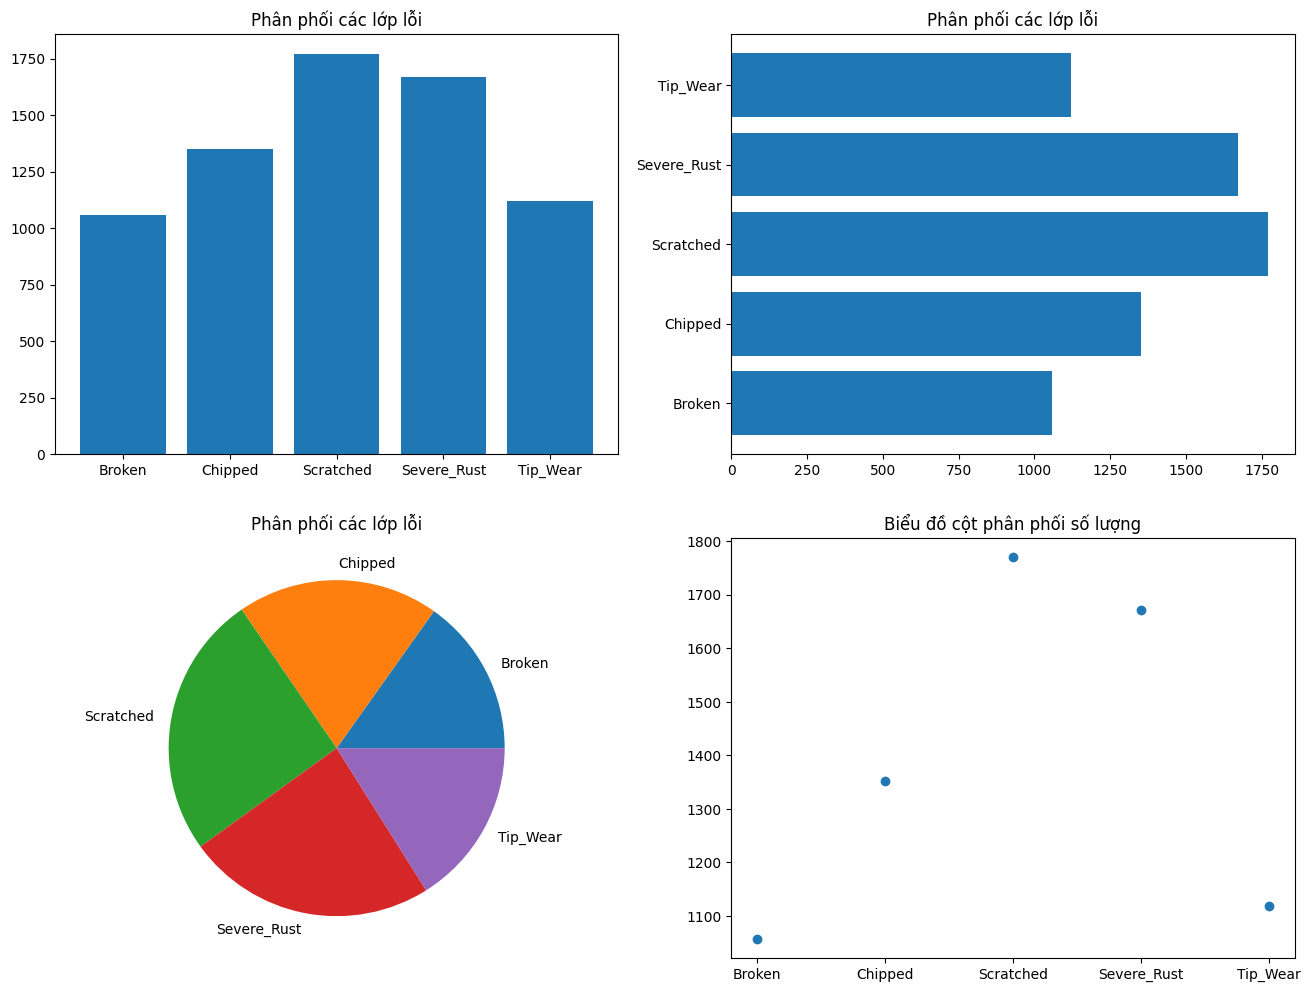

In [6]:
def visualize_class_distribution():
    names = []
    counts = []
    for class_id in range(NUM_CLASSES):
        names.append(CLASS_NAMES[class_id])
        counts.append(class_counts[class_id])
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes[0, 0].bar(names, counts)
    axes[0, 0].set_title("Phân phối các lớp lỗi")

    axes[0, 1].barh(names, counts)
    axes[0, 1].set_title("Phân phối các lớp lỗi")

    axes[1, 0].pie(counts, labels=names)
    axes[1, 0].set_title("Phân phối các lớp lỗi")

    axes[1, 1].scatter(names, counts)
    axes[1, 1].set_title("Biểu đồ cột phân phối số lượng")


    plt.show()
visualize_class_distribution()

# 5. Train Model YOLOv12

In [7]:


class DySample(nn.Module):
    """
    Lightweight Dynamic Upsampling
    """

    def __init__(self, c1, scale_factor=2, groups=2):
        super().__init__()

        self.scale_factor = scale_factor
        self.groups = groups

        # predict offsets
        self.offset = nn.Conv2d(
            c1,
            2 * groups * scale_factor * scale_factor,
            kernel_size=1
        )

        nn.init.normal_(self.offset.weight, std=0.001)
        nn.init.constant_(self.offset.bias, 0)

    def forward(self, x):

        B, C, H, W = x.shape
        s = self.scale_factor
        g = self.groups

        # offsets
        offset = self.offset(x)

        offset = F.pixel_shuffle(offset, s)
        offset = offset.to(x.dtype)

        offset = offset.view(B, 2, g, H * s, W * s)

        # base grid
        yy, xx = torch.meshgrid(
            torch.arange(H * s, device=x.device),
            torch.arange(W * s, device=x.device),
            indexing='ij'
        )

        grid = torch.stack((xx, yy), dim=0).to(x.dtype)

        # normalize
        grid[0] = 2.0 * grid[0] / max(W * s - 1, 1) - 1.0
        grid[1] = 2.0 * grid[1] / max(H * s - 1, 1) - 1.0

        grid = grid.unsqueeze(0).unsqueeze(2)

        grid = grid + offset / max(H * s, W * s)

        # split groups
        x = x.view(B, g, C // g, H, W)

        outputs = []

        for i in range(g):

            sampled = F.grid_sample(
                x[:, i],
                grid[:, :, i].permute(0, 2, 3, 1),
                mode='bilinear',
                padding_mode='border',
                align_corners=False
            )

            outputs.append(sampled)

        out = torch.cat(outputs, dim=1)

        return out


setattr(modules, 'DySample', DySample)
setattr(tasks, 'DySample', DySample)


yaml_content = '''
nc: 5

scales:
  n: [0.50, 0.25, 1024]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 2, C3k2, [256, False, 0.25]]

  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 2, C3k2, [512, False, 0.25]]

  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 4, A2C2f, [512, True, 4]]

  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 4, A2C2f, [1024, True, 1]]

head:
  # P5 -> P4
  - [-1, 1, DySample, [256, 2]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 2, A2C2f, [512, False, -1]]

  # P4 -> P3
  - [-1, 1, DySample, [128, 2]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 2, A2C2f, [256, False, -1]]

  # Downsample
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 11], 1, Concat, [1]]
  - [-1, 2, A2C2f, [512, False, -1]]

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 8], 1, Concat, [1]]
  - [-1, 2, C3k2, [1024, True]]

  - [[14, 17, 20], 1, Detect, [nc]]
'''

with open('yolov12n-dysample.yaml', 'w') as f:
    f.write(yaml_content)


In [8]:
model = YOLO("yolov12n-dysample.yaml").load("yolo12n.pt")
results = model.train(
    data='/kaggle/working/data.yaml', 
    epochs=300, 
    batch=16, 
    workers=4, 
    rect=False,              # Tắt rect để Mosaic 1.0 phát huy 100% tác dụng
    amp=True,

    # --- Tối ưu hóa lỗi Localization (Loc) ---
    imgsz=640, 
    box=9.5,
    dfl=2.0,

    # --- Tối ưu hóa lỗi Background (Bkg) ---
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    mosaic=1.0,
    mixup=0.1,               # Bật mixup nhẹ để khử nhiễu nền
    
    # --- Phép biến đổi khác ---
    scale=0.3,
    fliplr=0.5,
    flipud=0.5,
    erasing=0.05,
    copy_paste=0,
    close_mosaic=20,
    
    # --- Hyperparameters ---
    warmup_epochs=5,
    weight_decay=0.0005,
    patience=40,
    lr0=0.001,
    lrf=0.1,
    cos_lr=True,
    optimizer="AdamW"
)

Transferred 640/695 items from pretrained weights
Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=9.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=2.0, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.05, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov12n-dysample.yaml, momentum=0.937, mosaic=1.

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/300      3.44G       2.82      3.581      2.732         27        640: 100% ━━━━━━━━━━━━ 273/273 3.5it/s 1:18
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 2.3it/s 11.6s
                   all        844        959       0.47      0.104     0.0343    0.00969

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/300      4.09G      2.347      2.963      2.549         19        640: 0% ──────────── 0/273  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/300      4.09G      2.677      2.908      2.573         20        640: 100% ━━━━━━━━━━━━ 273/273 4.3it/s 1:04
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 4.3it/s 6.2s
                   all        844        959      0.184       0.34      0.144     0.0459

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/300      4.09G       2.55       2.69      2.659         29        640: 0% ──────────── 0/273  0.2s

...

    142/300      4.09G      1.768      1.221       1.83         19        640: 100% ━━━━━━━━━━━━ 273/273 4.4it/s 1:03
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 4.5it/s 6.1s
                   all        844        959      0.793      0.742      0.812      0.454

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    143/300      4.09G      2.253      1.524      2.109         42        640: 0% ──────────── 0/273  0.2s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    143/300      4.09G      1.775      1.222       1.83         18        640: 100% ━━━━━━━━━━━━ 273/273 4.4it/s 1:03
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 4.4it/s 6.1s
                   all        844        959      0.796      0.742       0.81      0.451

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    144/300      4.09G      1.772      1.177      1.767         33        640: 0% ──────────── 0/273  0.2s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    144/300      4.09G      1.779      1.237      1.837         20        640: 100% ━━━━━━━━━━━━ 273/273 4.3it/s 1:03
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 4.4it/s 6.1s
                   all        844        959      0.765      0.762      0.807      0.451
EarlyStopping: Training stopped early as no improvement observed in last 40 epochs. Best results observed at epoch 104, best model saved as best.pt.
To update EarlyStopping(patience=40) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

144 epochs completed in 2.773 hours.
Optimizer stripped from /kaggle/working/runs/detect/train/weights/last.pt, 5.5MB
Optimizer stripped from /kaggle/working/runs/detect/train/weights/best.pt, 5.5MB

Validating /kaggle/working/runs/detect/train/weights/best.pt...
Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv12n-dysample summary (fused): 159

# 6. Visualize kết quả


📊 Training Results:
   🎯 mAP50: 0.8072
   🎯 mAP50-95: 0.4505
   🎯 Precision: 0.7649
   🎯 Recall: 0.7618
   📦 Box loss: 1.9806
   🏷️  Cls loss: 1.0399
   🎯 DFL loss: 2.0376


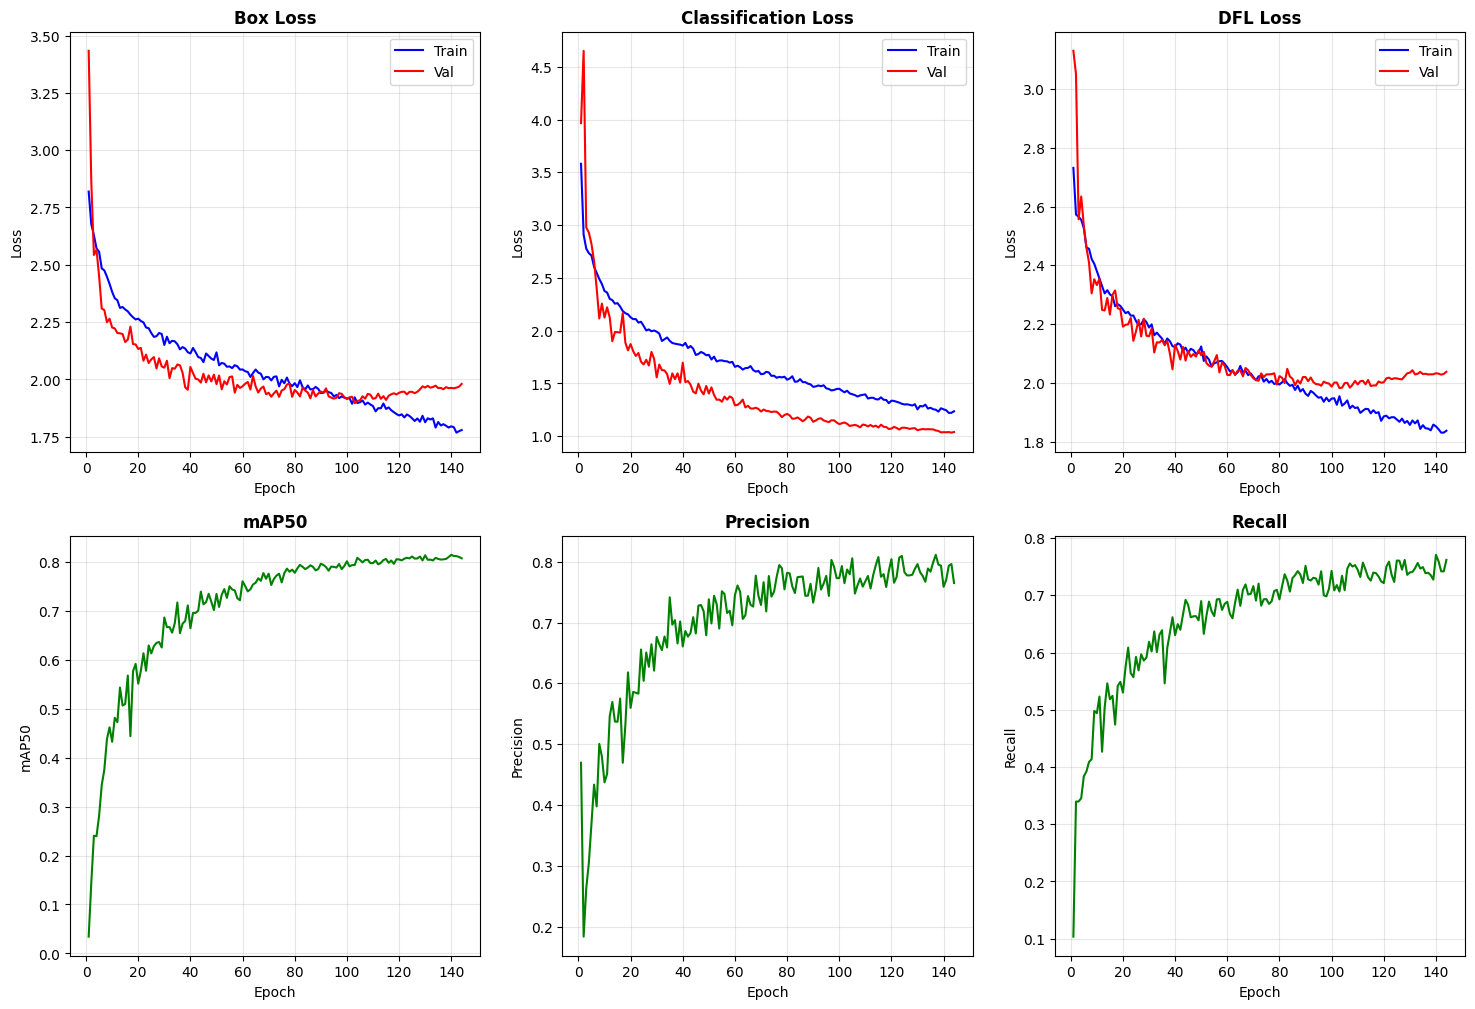

In [9]:
def visualize_training_loss(results_path):
    results_csv = Path(results_path) / "results.csv"
    df = pd.read_csv(results_csv)
    last_row = df.iloc[-1]
    final_metrics = {
            'mAP50': last_row.get('metrics/mAP50(B)', 0),
            'mAP50_95': last_row.get('metrics/mAP50-95(B)', 0),
            'precision': last_row.get('metrics/precision(B)', 0),
            'recall': last_row.get('metrics/recall(B)', 0),
            'box_loss': last_row.get('val/box_loss', 0),
            'cls_loss': last_row.get('val/cls_loss', 0),
            'dfl_loss': last_row.get('val/dfl_loss', 0)
        }
    
    # In kết quả cuối cùng
    print(f"\n📊 Training Results:")
    print(f"   🎯 mAP50: {final_metrics['mAP50']:.4f}")
    print(f"   🎯 mAP50-95: {final_metrics['mAP50_95']:.4f}")
    print(f"   🎯 Precision: {final_metrics['precision']:.4f}")
    print(f"   🎯 Recall: {final_metrics['recall']:.4f}")
    print(f"   📦 Box loss: {final_metrics['box_loss']:.4f}")
    print(f"   🏷️  Cls loss: {final_metrics['cls_loss']:.4f}")
    print(f"   🎯 DFL loss: {final_metrics['dfl_loss']:.4f}")

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    metrics = [
        ('train/box_loss', 'val/box_loss', 'Box Loss'),
        ('train/cls_loss', 'val/cls_loss', 'Classification Loss'),
        ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss')
    ]
    for idx, (train_metric, val_metric, title) in enumerate(metrics):
        ax = axes[0, idx]
        if train_metric in df.columns:
            ax.plot(df['epoch'], df[train_metric], label='Train', color='blue')
        if val_metric in df.columns:
            ax.plot(df['epoch'], df[val_metric], label='Val', color='red')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
    metric_plots = [
        ('metrics/mAP50(B)', 'mAP50'),
        ('metrics/precision(B)', 'Precision'),
        ('metrics/recall(B)', 'Recall')
    ]
    
    for idx, (metric, title) in enumerate(metric_plots):
        ax = axes[1, idx]
        if metric in df.columns:
            ax.plot(df['epoch'], df[metric], color='green')
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(title)
            ax.grid(True, alpha=0.3)
    plt.show()
    return final_metrics

final_metrics = visualize_training_loss('/kaggle/working/runs/detect/train')

# 7. Các biểu đồ đánh giá

--- Confusion Matrix ---


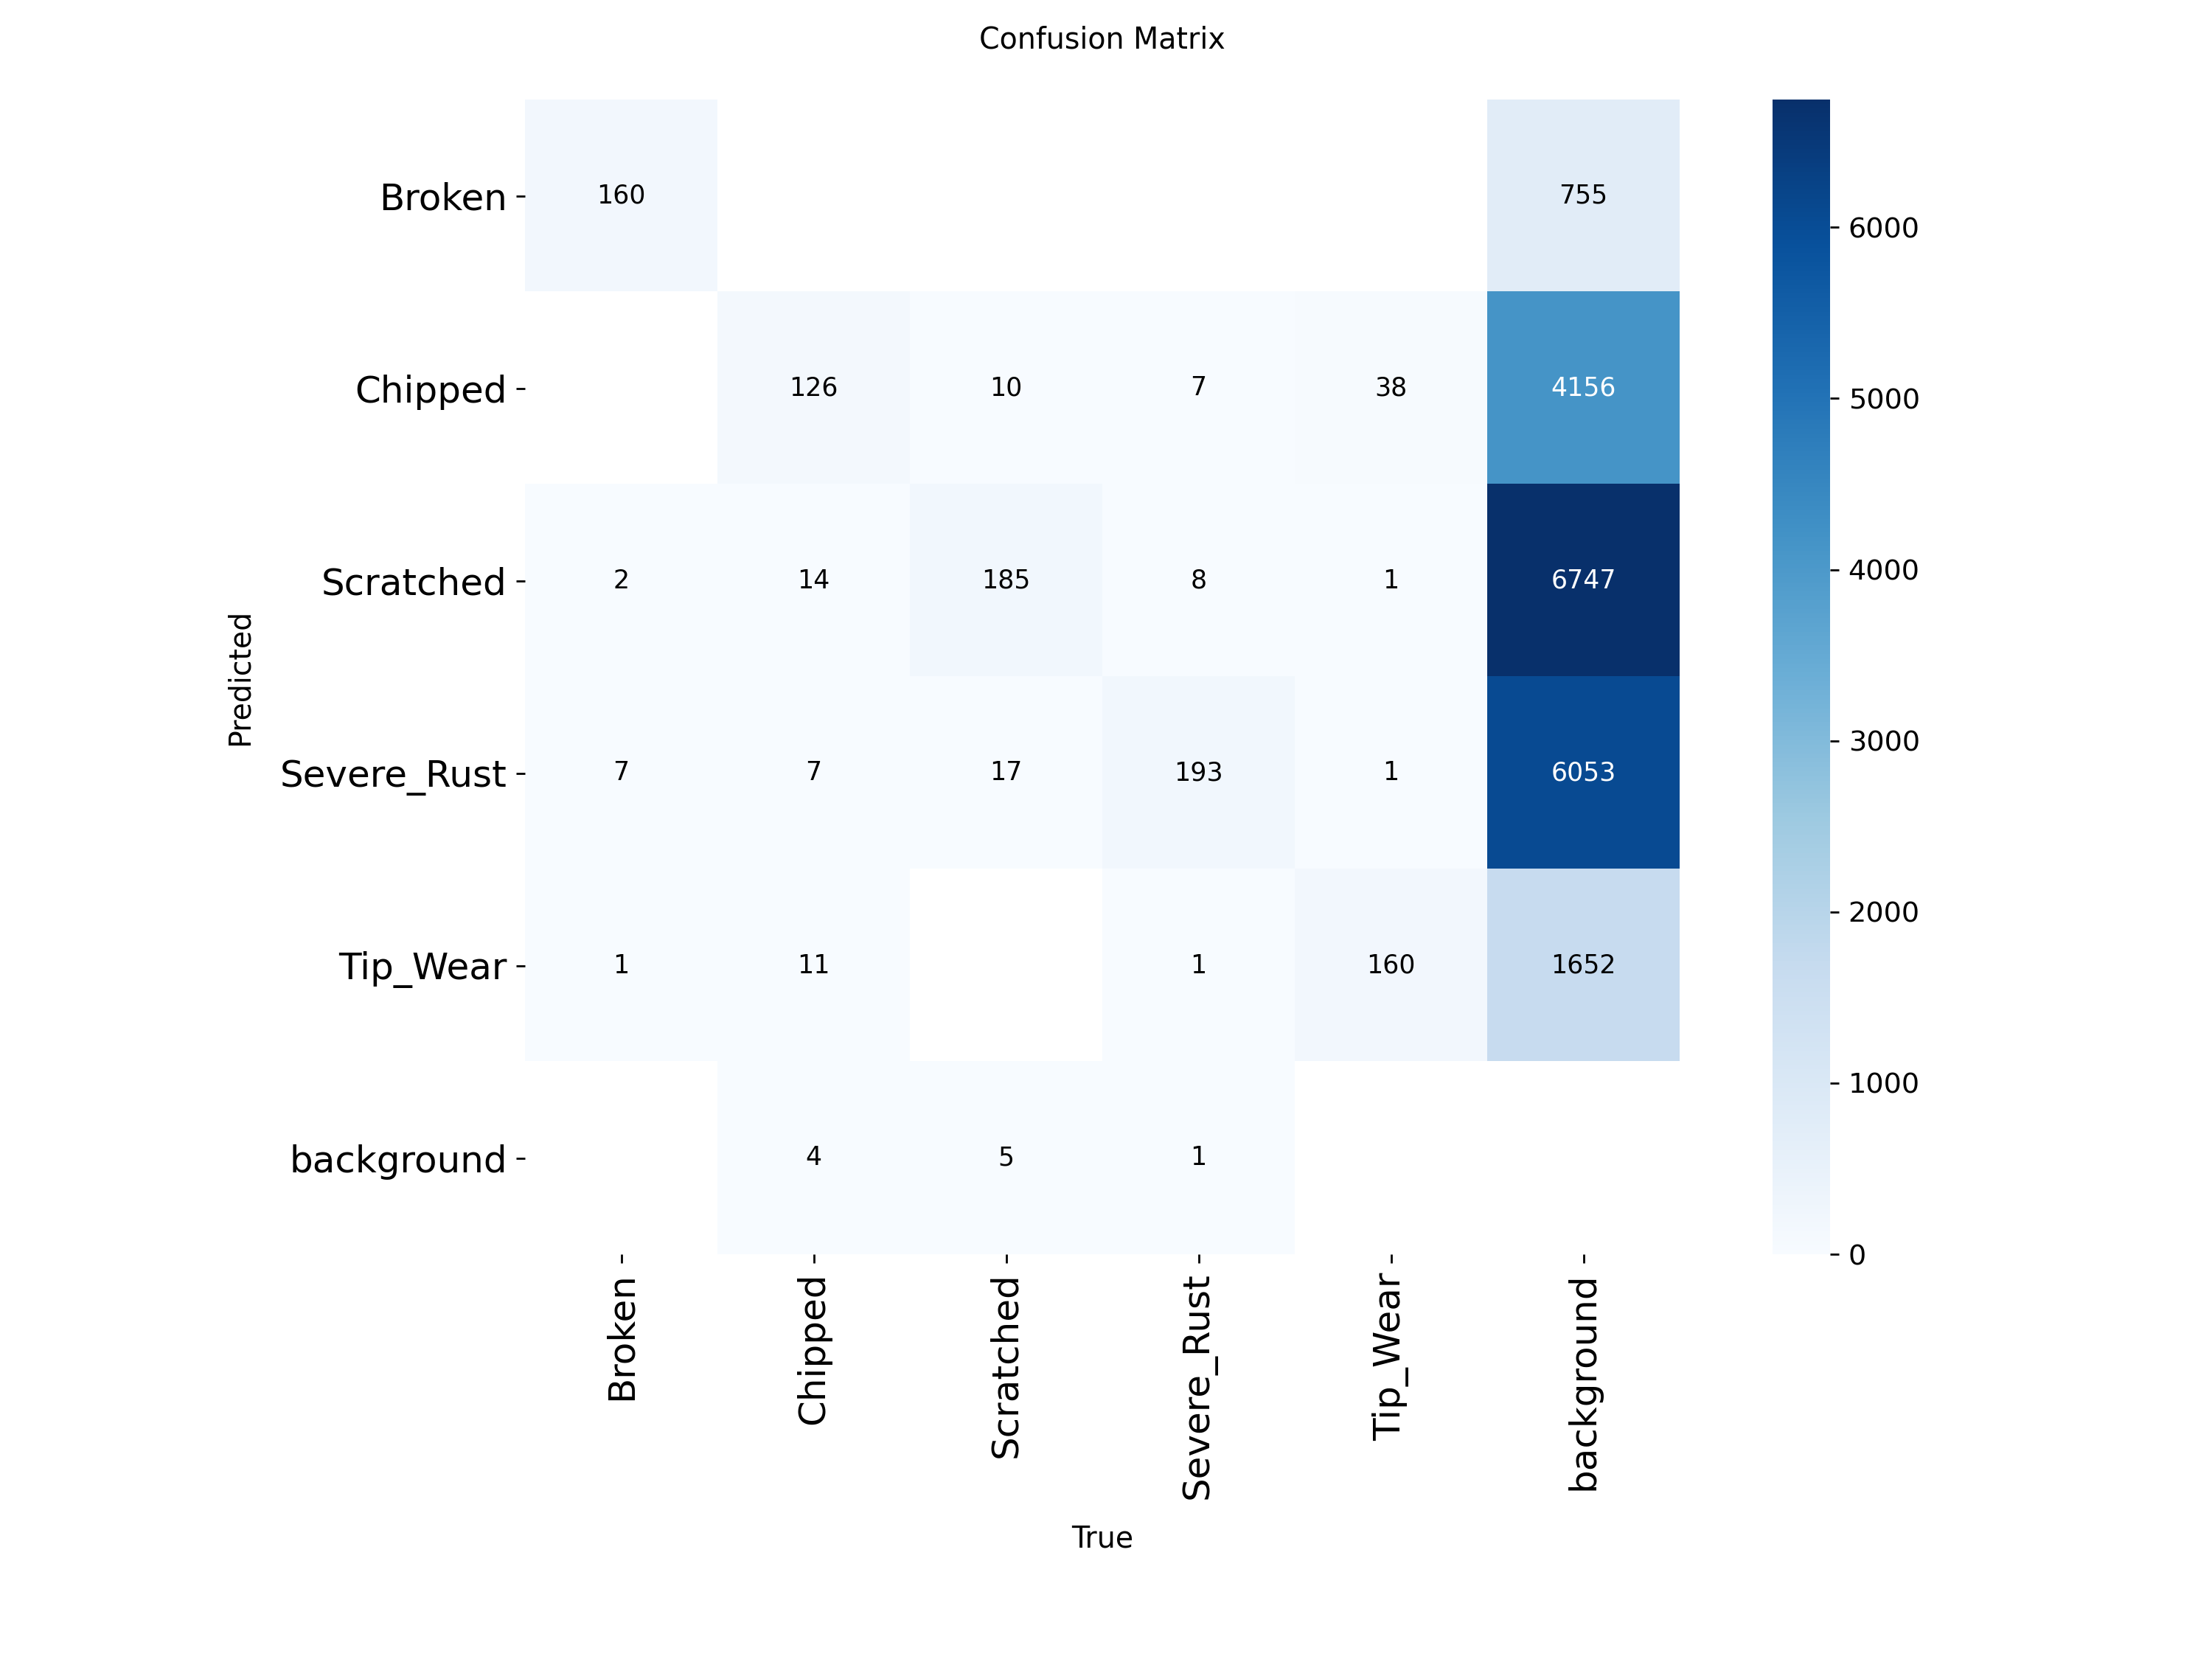

--- PR Curve ---


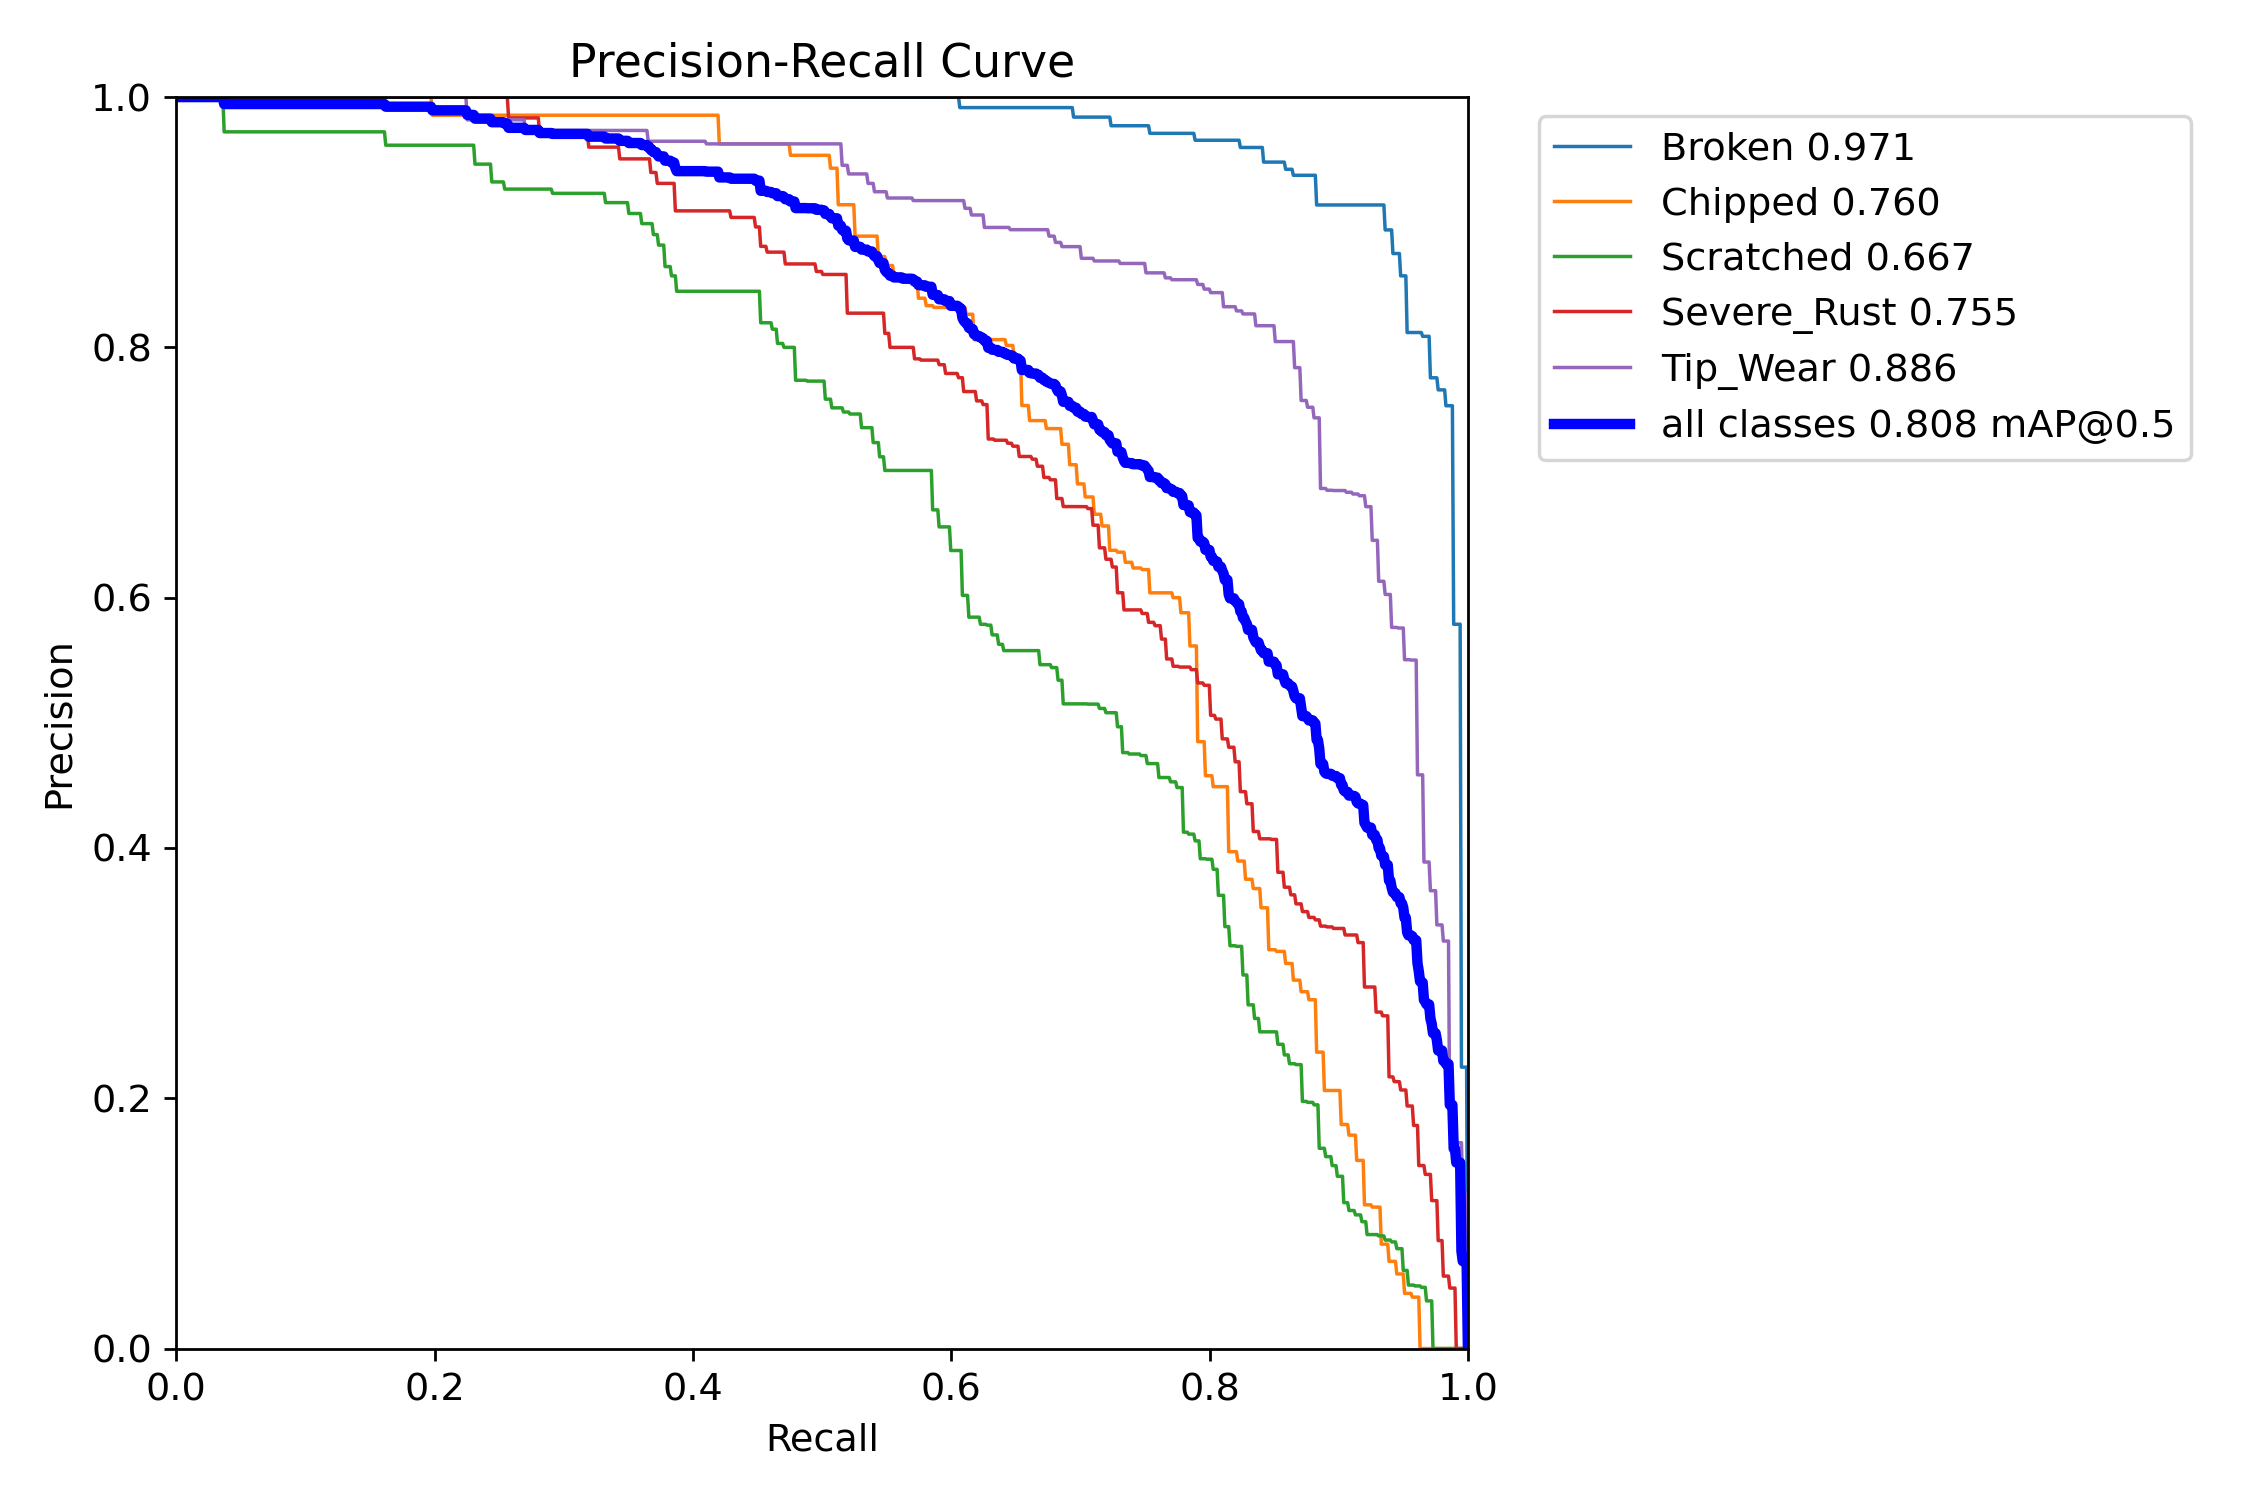

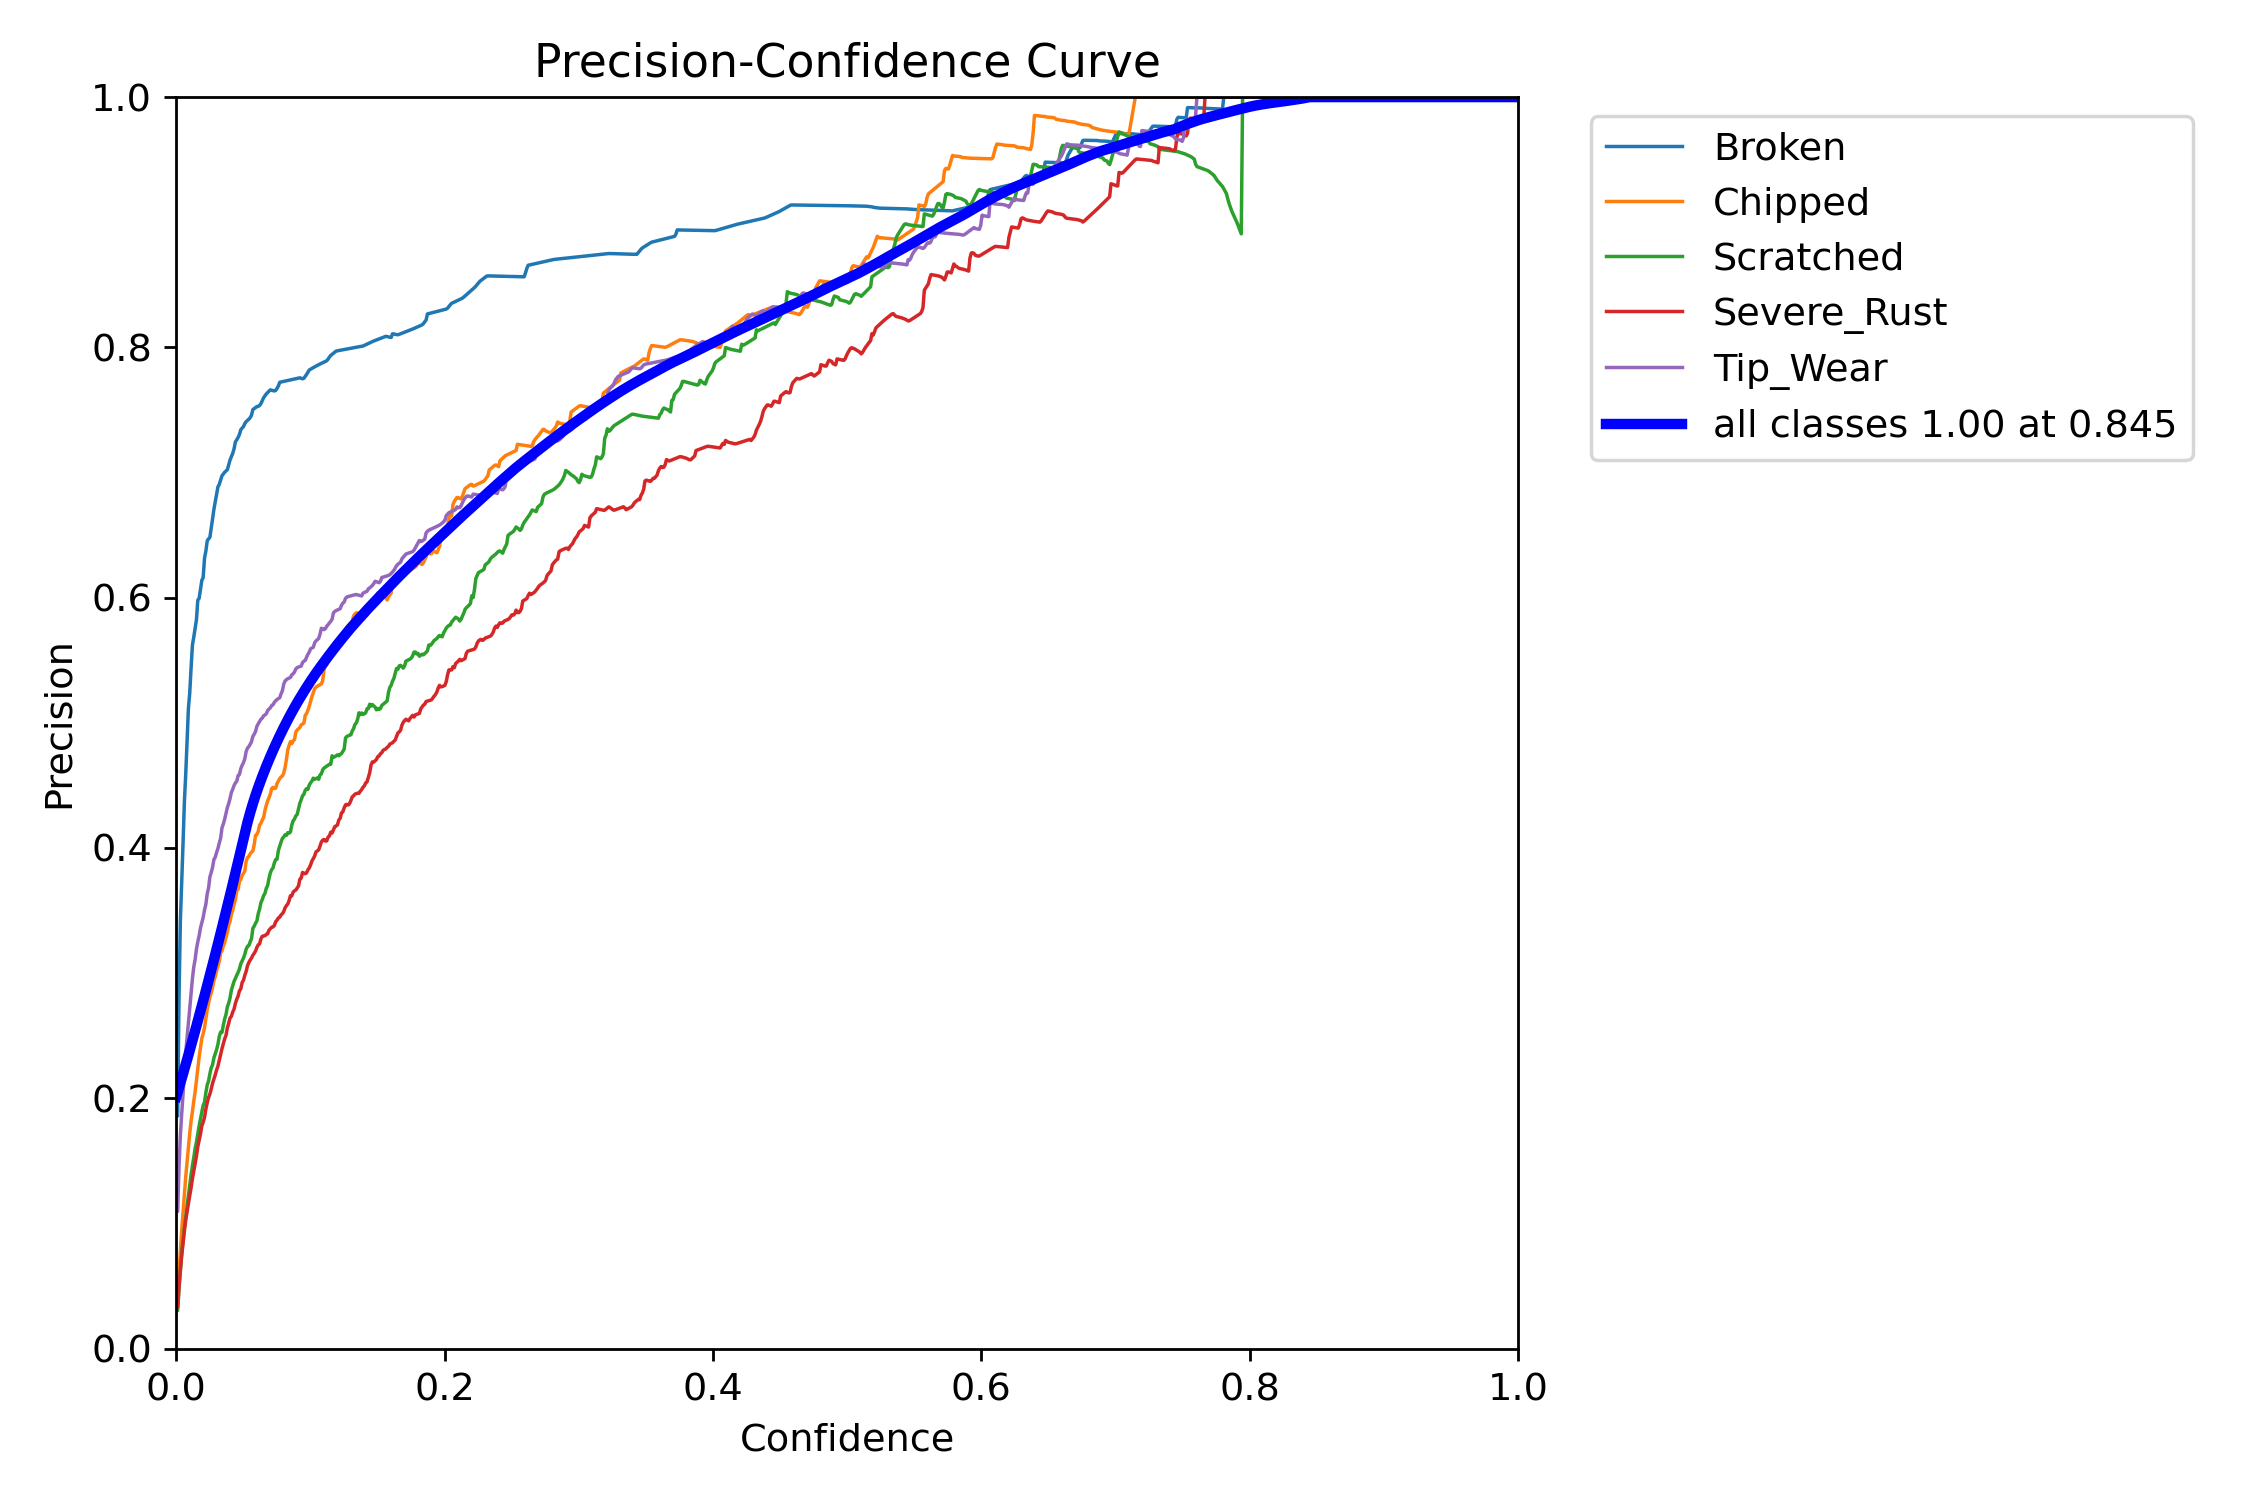

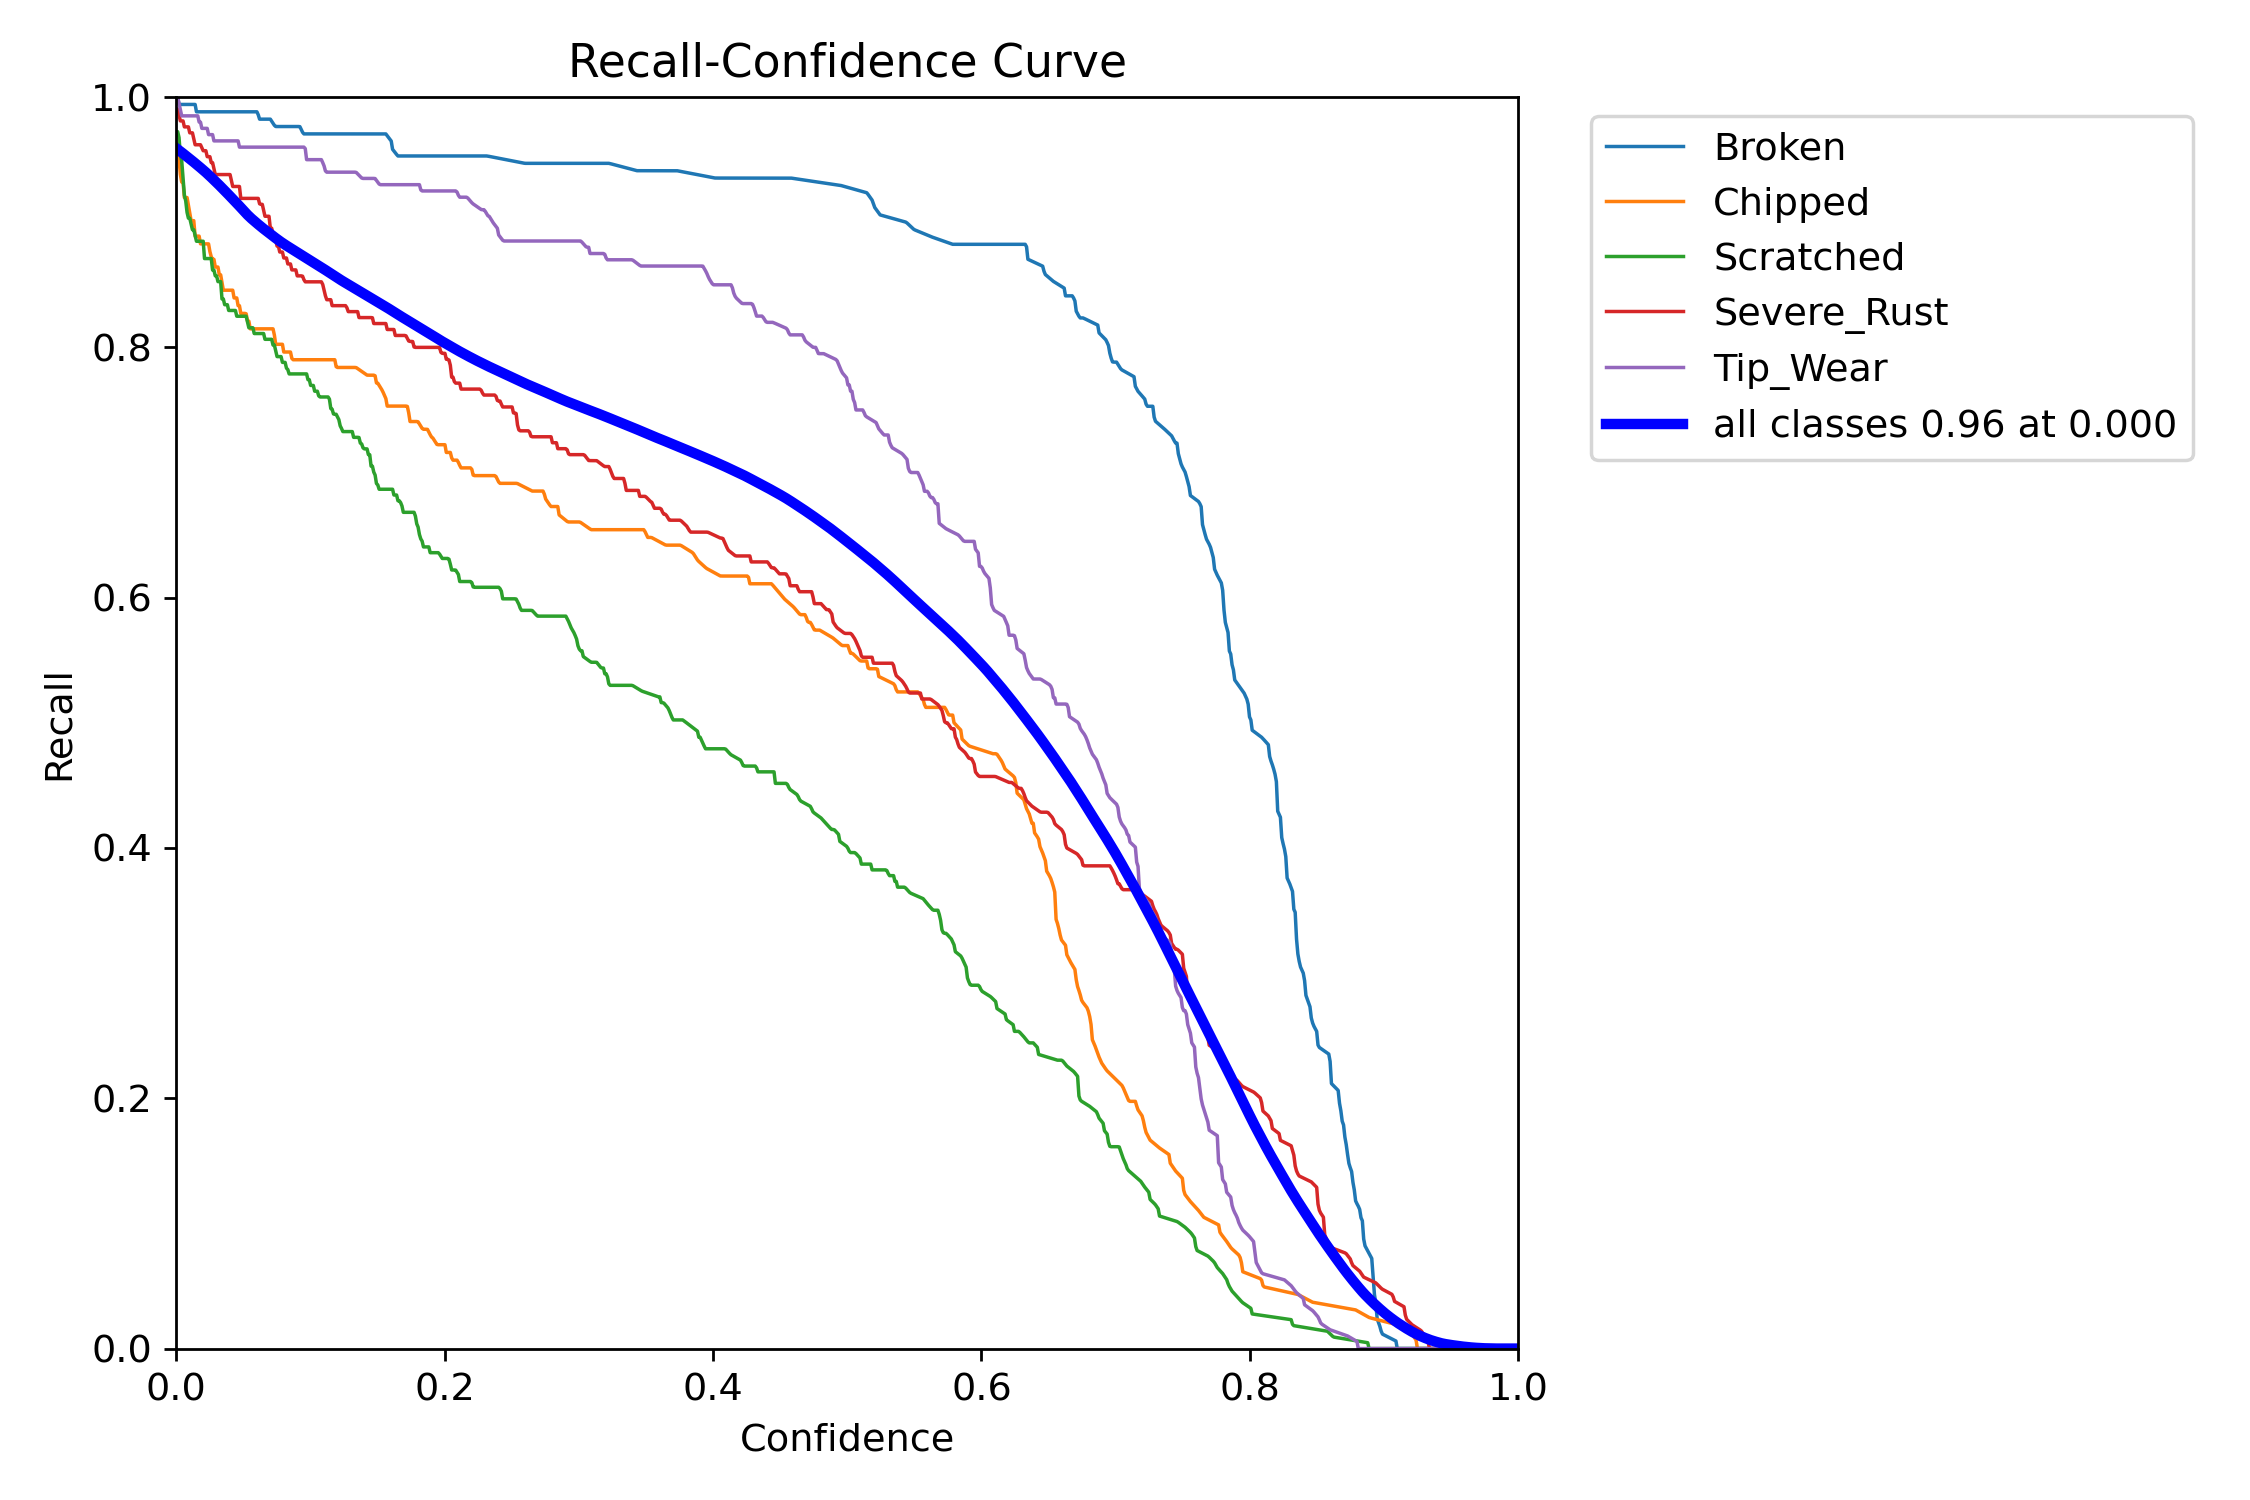

--- Loss & Metrics (Results) ---


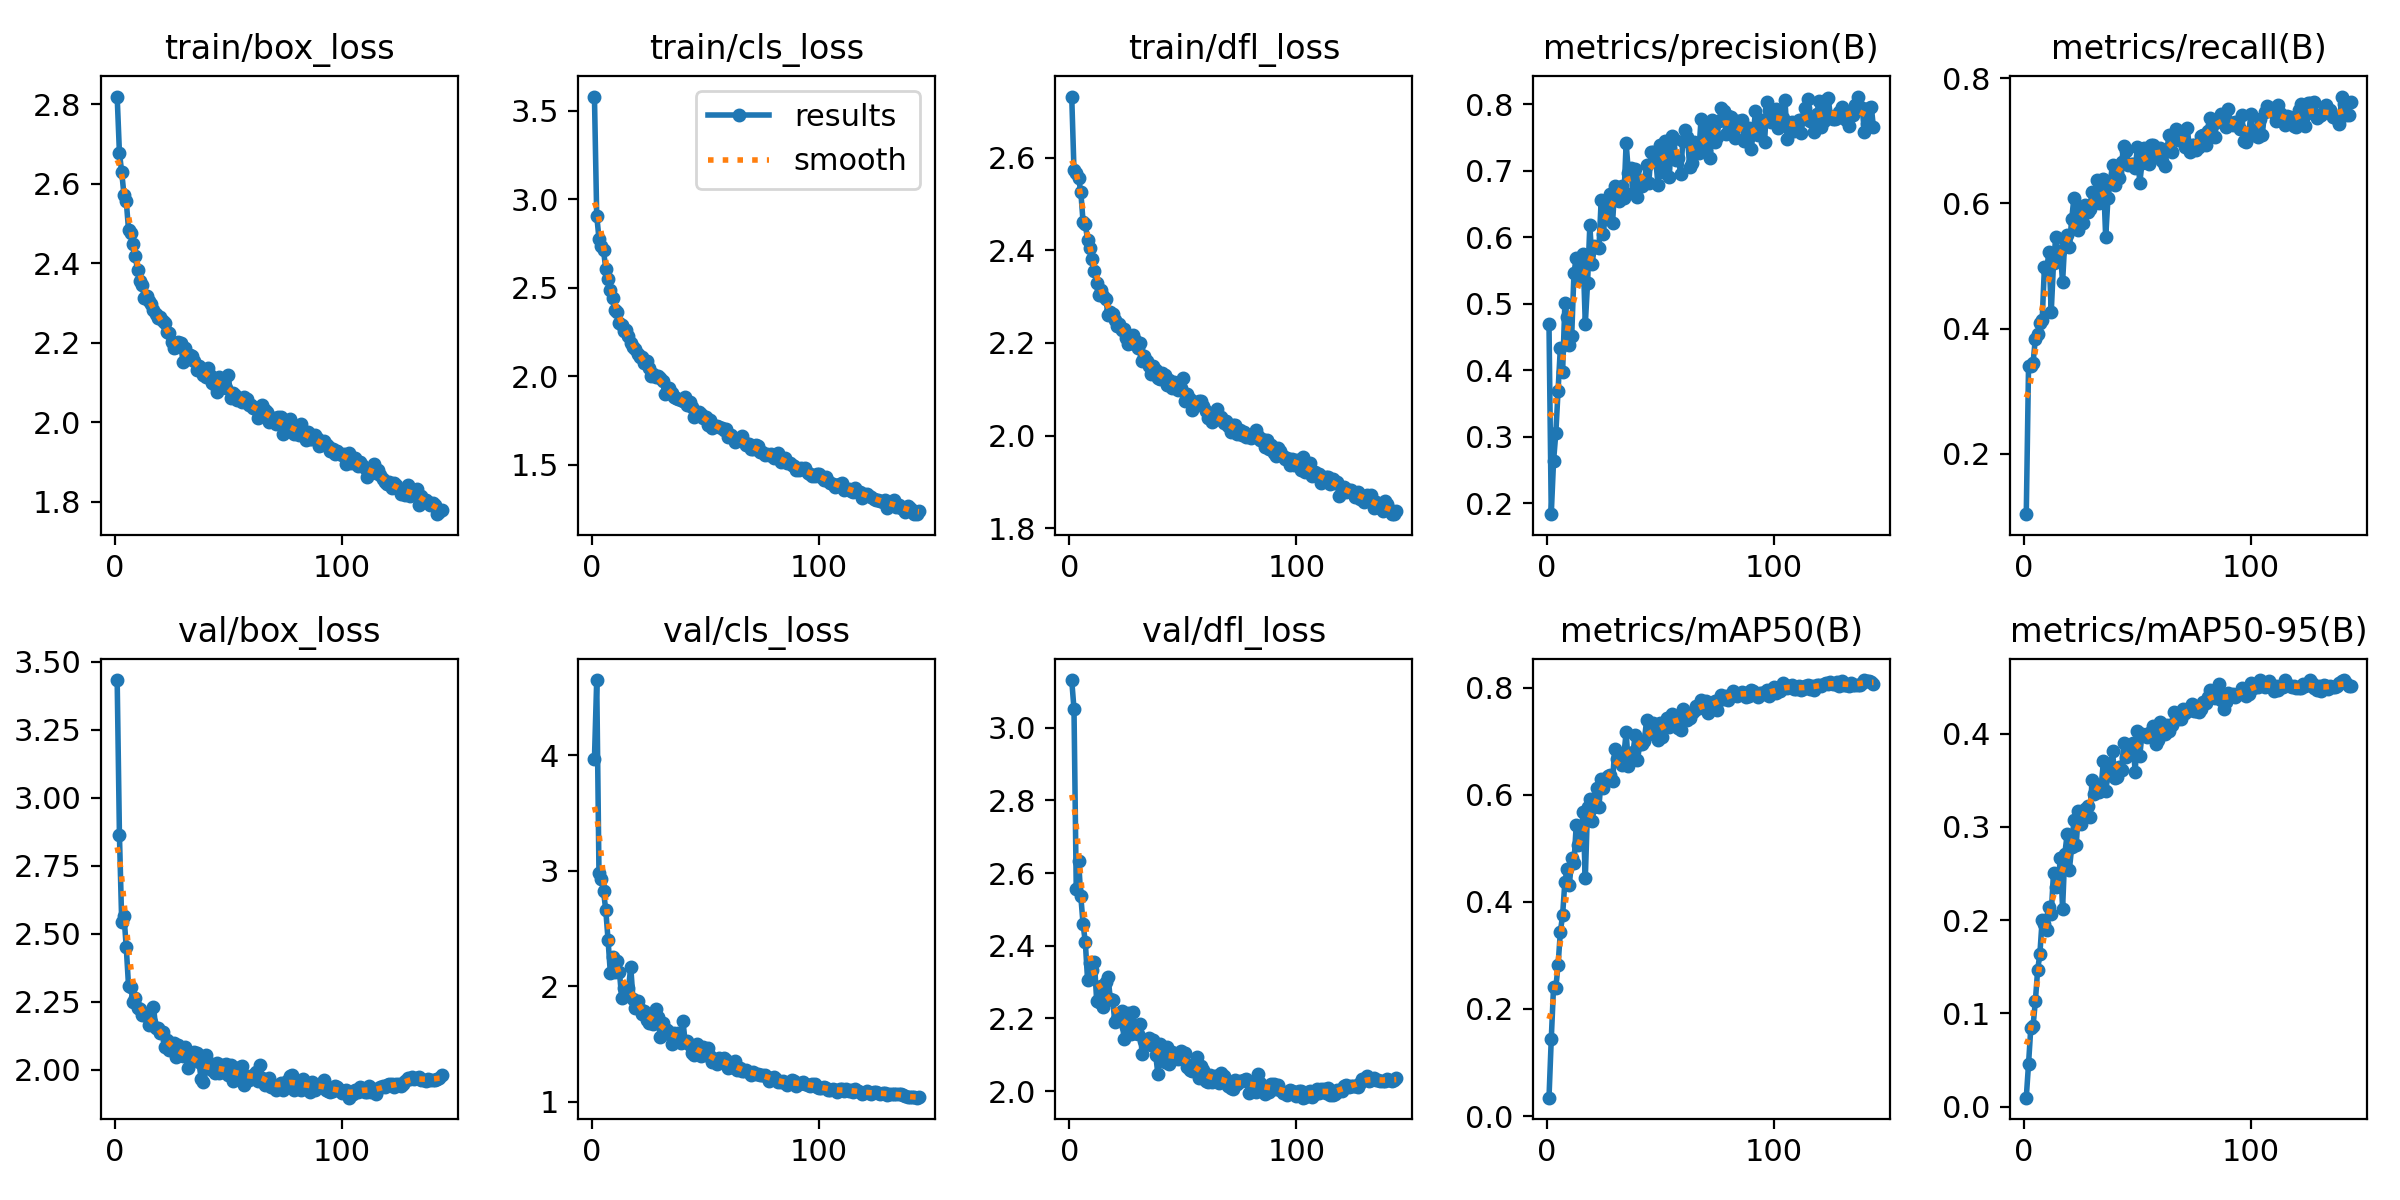

In [10]:
from IPython.display import Image, display

# Đường dẫn tới thư mục train
folder_path = '/kaggle/working/runs/detect/train/'

print("--- Confusion Matrix ---")
display(Image(filename=folder_path + 'confusion_matrix.png', width=1000))
print("--- PR Curve ---")
display(Image(filename=folder_path + 'BoxPR_curve.png', width=1000))
display(Image(filename=folder_path + 'BoxP_curve.png', width=1000))
display(Image(filename=folder_path + 'BoxR_curve.png', width=1000))

print("--- Loss & Metrics (Results) ---")
display(Image(filename=folder_path + 'results.png', width=1000))

# 8. Dự đoán

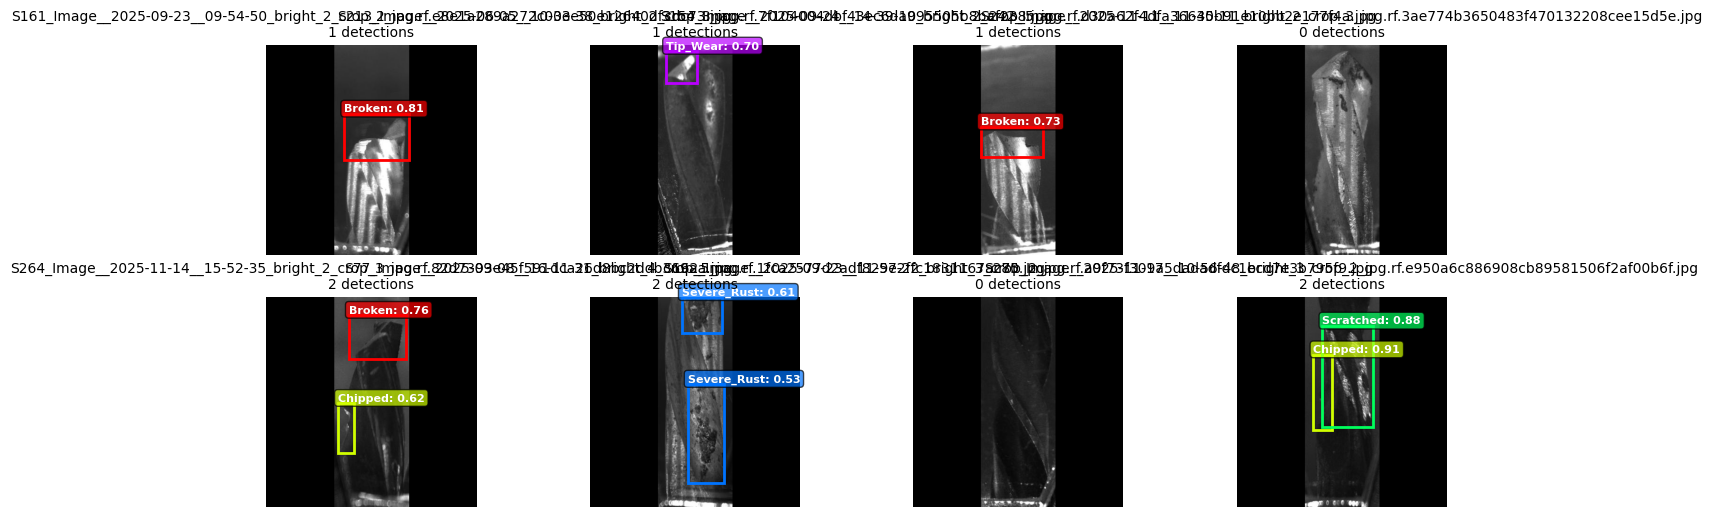


📊 Detection Summary:
   📷 Images: 8
   🎯 Detections: 9
   📈 Avg per image: 1.1
   📊 Avg confidence: 0.727
   📊 Max confidence: 0.911

🏷️  Class Distribution:
   Broken: 3
   Chipped: 2
   Severe_Rust: 2
   Tip_Wear: 1
   Scratched: 1


In [11]:
def predict_and_visualize(model_path, test_images_dir, num_samples=8, conf_threshold=0.5):
    model = YOLO(model_path)
    test_path = Path(test_images_dir)
    image_files = list(test_path.glob("*.jpg"))
    image_files = random.sample(image_files, min(num_samples, len(image_files)))
    NUM_CLASSES=5

    cols = min(4, len(image_files))
    rows = (len(image_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))

    if len(image_files) == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    total_detections = 0
    class_counts = Counter()
    confidences = []

    for idx, img_path in enumerate(image_files):
        ax = axes[idx] if len(image_files) > 1 else axes
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = model(str(img_path), conf=conf_threshold, verbose=False)
        detections = 0
        for result in results:
            if result.boxes is not None:
                for box in result.boxes:
                    detections += 1
                    total_detections += 1
                    
                    # Get box coordinates
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    conf = box.conf[0].cpu().numpy()
                    cls_id = int(box.cls[0].cpu().numpy())
                    
                    confidences.append(conf)
                    class_counts[cls_id] += 1
                    
                    # Draw bounding box
                    color = plt.cm.hsv(cls_id / NUM_CLASSES
                                      )[:3]
                    rect = patches.Rectangle(
                        (x1, y1), x2 - x1, y2 - y1,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)
                    
                    # Add label
                    label = f"{CLASS_NAMES[cls_id]}: {conf:.2f}"
                    ax.text(x1, y1 - 5, label, 
                            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7),
                            fontsize=8, color='white', fontweight='bold')
        
        ax.imshow(img_rgb)
        ax.set_title(f"{img_path.name}\n{detections} detections", fontsize=10)
        ax.axis('off')

        # Hide unused axes
    for idx in range(len(image_files), len(axes)):
        axes[idx].axis('off')
    plt.show()
    
    # Print statistics
    print(f"\n📊 Detection Summary:")
    print(f"   📷 Images: {len(image_files)}")
    print(f"   🎯 Detections: {total_detections}")
    print(f"   📈 Avg per image: {total_detections/len(image_files):.1f}")
    print(f"   📊 Avg confidence: {np.mean(confidences):.3f}" if confidences else "   📊 Avg confidence: N/A")
    print(f"   📊 Max confidence: {np.max(confidences):.3f}" if confidences else "   📊 Max confidence: N/A")
    
    print(f"\n🏷️  Class Distribution:")
    for cls_id, count in class_counts.most_common():
        print(f"   {CLASS_NAMES[cls_id]}: {count}")
    
    return {
        'total_detections': total_detections,
        'class_counts': dict(class_counts),
        'avg_confidence': np.mean(confidences) if confidences else 0
    }

prediction_results = predict_and_visualize(
    model_path='/kaggle/working/runs/detect/train/weights/best.pt',
    test_images_dir=str(DATASET_PATH / 'test' / 'Bright_Field' /'images'),
    num_samples=8,
    conf_threshold=0.5
)

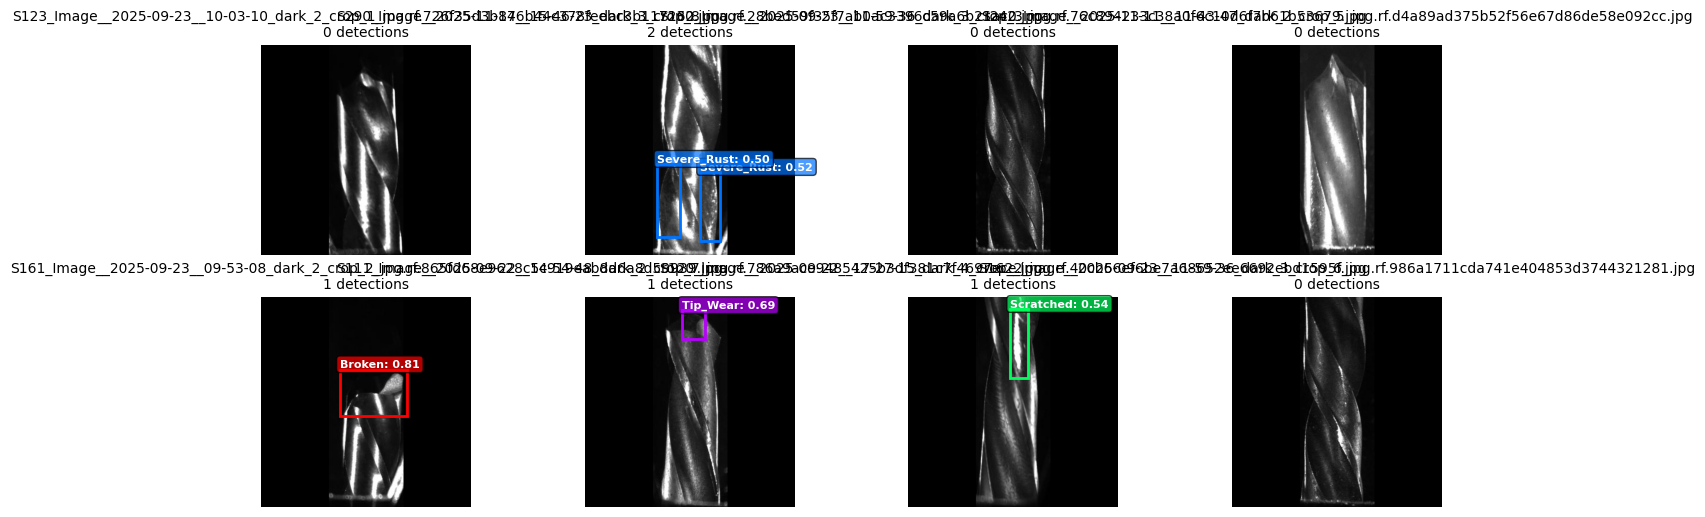


📊 Detection Summary:
   📷 Images: 8
   🎯 Detections: 5
   📈 Avg per image: 0.6
   📊 Avg confidence: 0.612
   📊 Max confidence: 0.811

🏷️  Class Distribution:
   Severe_Rust: 2
   Broken: 1
   Tip_Wear: 1
   Scratched: 1


In [12]:
def predict_and_visualize(model_path, test_images_dir, num_samples=8, conf_threshold=0.5):
    model = YOLO(model_path)
    test_path = Path(test_images_dir)
    image_files = list(test_path.glob("*.jpg"))
    image_files = random.sample(image_files, min(num_samples, len(image_files)))
    NUM_CLASSES=5

    cols = min(4, len(image_files))
    rows = (len(image_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))

    if len(image_files) == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    total_detections = 0
    class_counts = Counter()
    confidences = []

    for idx, img_path in enumerate(image_files):
        ax = axes[idx] if len(image_files) > 1 else axes
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = model(str(img_path), conf=conf_threshold, verbose=False)
        detections = 0
        for result in results:
            if result.boxes is not None:
                for box in result.boxes:
                    detections += 1
                    total_detections += 1
                    
                    # Get box coordinates
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    conf = box.conf[0].cpu().numpy()
                    cls_id = int(box.cls[0].cpu().numpy())
                    
                    confidences.append(conf)
                    class_counts[cls_id] += 1
                    
                    # Draw bounding box
                    color = plt.cm.hsv(cls_id / NUM_CLASSES)[:3]
                    rect = patches.Rectangle(
                        (x1, y1), x2 - x1, y2 - y1,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)
                    
                    # Add label
                    label = f"{CLASS_NAMES[cls_id]}: {conf:.2f}"
                    ax.text(x1, y1 - 5, label, 
                            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7),
                            fontsize=8, color='white', fontweight='bold')
        
        ax.imshow(img_rgb)
        ax.set_title(f"{img_path.name}\n{detections} detections", fontsize=10)
        ax.axis('off')

        # Hide unused axes
    for idx in range(len(image_files), len(axes)):
        axes[idx].axis('off')
    plt.show()
    
    # Print statistics
    print(f"\n📊 Detection Summary:")
    print(f"   📷 Images: {len(image_files)}")
    print(f"   🎯 Detections: {total_detections}")
    print(f"   📈 Avg per image: {total_detections/len(image_files):.1f}")
    print(f"   📊 Avg confidence: {np.mean(confidences):.3f}" if confidences else "   📊 Avg confidence: N/A")
    print(f"   📊 Max confidence: {np.max(confidences):.3f}" if confidences else "   📊 Max confidence: N/A")
    
    print(f"\n🏷️  Class Distribution:")
    for cls_id, count in class_counts.most_common():
        print(f"   {CLASS_NAMES[cls_id]}: {count}")
    
    return {
        'total_detections': total_detections,
        'class_counts': dict(class_counts),
        'avg_confidence': np.mean(confidences) if confidences else 0
    }

prediction_results = predict_and_visualize(
    model_path='/kaggle/working/runs/detect/train/weights/best.pt',
    test_images_dir=str(DATASET_PATH / 'test' / 'Dark_Field' /'images'),
    num_samples=8,
    conf_threshold=0.5
)

# 9. Đánh giá mô hình trên tập test

In [13]:
# 10. ĐÁNH GIÁ MÔ HÌNH TRÊN TEST SET
# ============================================================
from ultralytics import YOLO
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')  

def evaluate_model(model):    
    # Chạy validation
    metrics = model.val(data=str(data_yaml_path), split='test')

    # 1. Lấy F1-score (thường lấy tại index của confidence threshold ~0.5)
    # metrics.box.f1 trả về mảng F1 cho mỗi class
    f1_scores = metrics.box.f1
    mean_f1 = f1_scores.mean()

    # 2. Tính toán FPS
    # speed_stats bao gồm: 'preprocess', 'inference', 'loss', 'postprocess'
    speed = metrics.speed
    latency_per_img = speed['preprocess'] + speed['inference'] + speed['postprocess']
    fps = 1000 / latency_per_img

    print(f"\n📊 Evaluation Results:")
    print(f"   🎯 Mean F1-Score: {mean_f1:.4f}")
    print(f"   ⚡ FPS: {fps:.2f} ({latency_per_img:.2f} ms/ảnh)")

    # 3. In F1 per Class
    print(f"\n📈 F1 per Class:")
    # Sử dụng metrics.names để đảm bảo mapping chính xác
    for i, class_id in enumerate(metrics.ap_class_index):
        class_name = model.names[class_id]
        print(f"   🔹 {class_name}: {f1_scores[i]:.4f}")

    return {
        "mean_f1": mean_f1,
        "fps": fps
    }
data_yaml_path='data.yaml'
evaluate_model(model)


Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv12n-dysample summary (fused): 159 layers, 2,563,879 parameters, 0 gradients, 7.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 1.8±0.5 MB/s, size: 10.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/abcnexttt/data-after-handle/data_convert_yolo_format/test/Bright_Field/labels... 546 images, 158 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 704/704 422.9it/s 1.7s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/abcnexttt/data-after-handle/data_convert_yolo_format/test/Bright_Field is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 5.8it/s 7.5s
                   all        704        758      0.782      0.711      0.795       0.44
             

{'mean_f1': np.float64(0.7379566741285528), 'fps': 121.98423379874747}